# Travel Mode Choice Modeling

Exploratory analysis, preprocessing, and modeling using XGBoost and CatBoost.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [3]:
df = pd.read_csv('mode_choice_data.csv')
df.head()

,id,Travel_Time,travel_cost,\tcomfort,reliability,safety,accessibility,service_frequency,\twait_time,in_vehicle_time,...,age,gender,marital,people,yrsjob,cusinter,yrsfirm,educ,income,travel_mode
0,1,6,7,5,6,7,6,6,6,6,...,32,2,3.0,1,2,80.0,3.0,2,2.0,3
1,3,7,6,7,7,6,7,7,7,7,...,25,2,2.0,1,0,55.0,3.0,2,2.0,2
2,11,7,7,4,6,7,5,6,6,6,...,21,2,1.0,3,1,180.0,1.0,2,2.0,3
3,12,6,6,6,6,4,6,6,6,6,...,22,2,4.0,6,0,200.0,3.0,2,2.0,3
4,14,5,6,5,5,6,4,7,4,5,...,38,2,1.0,5,2,999.0,2.0,1,2.0,3


## Basic Info

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Columns: 105 entries, id to travel_mode
dtypes: float64(5), int64(100)
memory usage: 250.3 KB


,id,Travel_Time,travel_cost,\tcomfort,reliability,safety,accessibility,service_frequency,\twait_time,in_vehicle_time,...,age,gender,marital,people,yrsjob,cusinter,yrsfirm,educ,income,travel_mode
count,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,...,305.000000,305.000000,303.000000,305.000000,305.000000,289.000000,304.000000,305.000000,303.000000,305.000000
mean,246.937705,5.570492,5.924590,4.872131,5.691803,5.868852,5.567213,5.527869,5.662295,5.629508,...,30.908197,1.740984,1.877888,3.360656,1.668852,104.252595,2.493421,1.849180,1.980198,2.901639
std,145.598400,1.162368,1.053293,1.555987,1.228807,1.086330,1.311478,1.287609,1.192378,1.212781,...,10.009113,0.438815,1.277002,1.724750,1.191464,86.006633,1.344819,0.732386,0.422391,1.080706
min,1.000000,2.000000,3.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,...,18.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
25%,123.000000,5.000000,6.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,24.000000,1.000000,1.000000,2.000000,1.000000,50.000000,2.000000,1.000000,2.000000,2.000000
50%,235.000000,6.000000,6.000000,5.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,28.000000,2.000000,1.000000,3.000000,2.000000,100.000000,3.000000,2.000000,2.000000,3.000000
75%,376.000000,6.000000,7.000000,6.000000,7.000000,7.000000,7.000000,6.000000,7.000000,7.000000,...,36.000000,2.000000,3.000000,4.000000,3.000000,130.000000,3.000000,2.000000,2.000000,4.000000
max,499.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,...,73.000000,2.000000,5.000000,10.000000,10.000000,999.000000,15.000000,5.000000,4.000000,5.000000


## Target Distribution

In [5]:
df['travel_mode'].value_counts()

travel_mode
2    101
4     85
3     76
1     25
5     18
Name: count, dtype: int64

## Missing Values

In [6]:
df.isnull().sum().sort_values(ascending=False).head(20)

cusinter                16
marital                  2
income                   2
road_condition           1
yrsfirm                  1
Travel_Time              0
travel_cost              0
\tcomfort                0
id                       0
in_vehicle_time          0
crowding                 0
seat_availability        0
route_directness         0
transfer_ease            0
parking_availability     0
fare_integration         0
ticketing_ease           0
service_image            0
habitual_mode_choice     0
perceived_safety         0
dtype: int64

## Preprocessing

In [7]:
# Separate features and target
X = df.drop(columns=['travel_mode'])
y = df['travel_mode']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## XGBoost Model

In [ ]:
xgb_model = XGBClassifier(eval_metric='mlogloss', use_label_encoder=False)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4], got [1 2 3 4 5]

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.show()

## CatBoost Model

In [ ]:
cat_model = CatBoostClassifier(verbose=0)
cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_cat))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cat))


In [ ]:
cm = confusion_matrix(y_test, y_pred_cat)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("CatBoost Confusion Matrix")
plt.show()

c:\Users\rosha\Documents\traffic_new\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dropped features: ['social_influence', '\tpedestrian_priority']


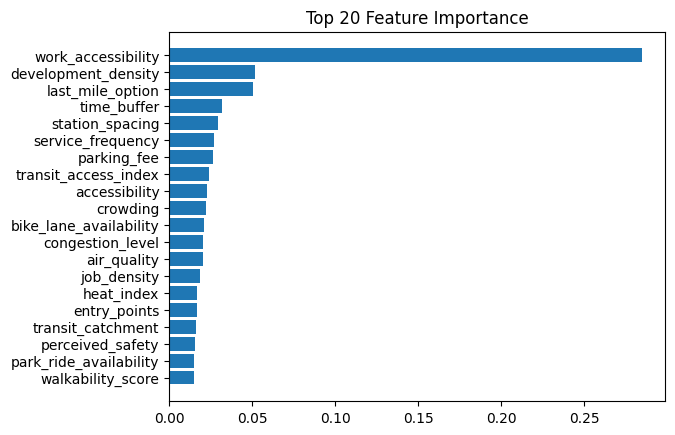

ValueError: could not convert string to float: '[-6.7618763E-1,7.225201E-1,4.389459E-1,5.475793E-1,-1.0328573E0]'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Load data
df = pd.read_csv("mode_choice_data.csv")

# Split
X = df.drop(columns=["travel_mode"])
y = df["travel_mode"]

# Fix labels (important for XGBoost)
y = y - y.min()

# Handle missing values
X = X.fillna(X.median(numeric_only=True))

# Correlation filtering
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
X = X.drop(columns=to_drop)

print("Dropped features:", to_drop)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
model = XGBClassifier(eval_metric='mlogloss')
model.fit(X_train, y_train)

# -------------------------
# Feature Importance
# -------------------------
importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance_df["feature"][:20][::-1],
         feature_importance_df["importance"][:20][::-1])
plt.title("Top 20 Feature Importance")
plt.show()

# -------------------------
# SHAP
# -------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

# -------------------------
# Save Excel
# -------------------------
with pd.ExcelWriter("feature_analysis.xlsx") as writer:
    feature_importance_df.to_excel(writer, sheet_name="Feature Importance", index=False)
    pd.DataFrame(to_drop, columns=["Dropped Features"]).to_excel(writer, sheet_name="Dropped Features", index=False)